<a href="https://www.kaggle.com/code/lalit7881/ai-data-science-job-salaries-2026-eda?scriptVersionId=341468352" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv


In [2]:
import warnings
warnings.simplefilter('ignore')
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid')

from pathlib import Path

# For model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print('Imports set up. Let the data exploration begin (or at least pretend to)!')

Imports set up. Let the data exploration begin (or at least pretend to)!


## Loading dataset

In [3]:
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Test the file resolution (this line will not print the actual path but confirms functionality)
data_file_path = resolve_data_file('ai_ds_job_salaries_2026.csv', suffixes=['.csv'])
print(f'Resolved data file to: {data_file_path}')

Resolved data file to: /kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv


In [4]:
# Load the dataset using the resolved path
df = pd.read_csv(data_file_path, encoding='ascii', delimiter=',')
print('Data loaded successfully.')

Data loaded successfully.


In [5]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (5000, 27)


In [6]:
# Quick summary of the dataset
print('Data types:')
print(df.dtypes)

Data types:
job_title                      object
experience_level               object
employment_type                object
company_size                   object
company_location               object
employee_residence             object
industry                       object
remote_ratio                    int64
years_experience              float64
education_level                object
primary_language               object
has_ml_in_title                  bool
manages_people                   bool
team_size                       int64
certifications_count            int64
weekly_hours                  float64
uses_ai_tools_daily              bool
ai_tools_hours_per_week       float64
salary_currency                object
salary_usd                      int64
equity_offered_pct            float64
bonus_pct                     float64
job_satisfaction_score        float64
interviews_to_offer             int64
switched_jobs_last_year          bool
upskilling_hours_per_month    float64


In [7]:
# Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())



Missing values per column:
job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64


In [8]:
numeric_df = df.select_dtypes(include=[np.number])
print(f'Numeric columns for analysis: {list(numeric_df.columns)}')

Numeric columns for analysis: ['remote_ratio', 'years_experience', 'team_size', 'certifications_count', 'weekly_hours', 'ai_tools_hours_per_week', 'salary_usd', 'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score', 'interviews_to_offer', 'upskilling_hours_per_month', 'fears_ai_automation_score']


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

job_title                       12
experience_level                 5
employment_type                  4
company_size                     3
company_location                12
employee_residence              12
industry                        10
remote_ratio                     3
years_experience               230
education_level                  5
primary_language                 7
has_ml_in_title                  2
manages_people                   2
team_size                       19
certifications_count             9
weekly_hours                   344
uses_ai_tools_daily              2
ai_tools_hours_per_week        240
salary_currency                  9
salary_usd                    4928
equity_offered_pct             684
bonus_pct                      258
job_satisfaction_score          80
interviews_to_offer             16
switched_jobs_last_year          2
upskilling_hours_per_month     217
fears_ai_automation_score       91
dtype: int64

In [11]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'remote_ratio',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'team_size',
       'certifications_count', 'weekly_hours', 'uses_ai_tools_daily',
       'ai_tools_hours_per_week', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'upskilling_hours_per_month', 'fears_ai_automation_score'],
      dtype='object')

## EDA

First Five Rows
                   job_title experience_level employment_type company_size  \
0               Data Analyst             Lead       Part-time            S   
1         Research Scientist           Senior       Full-time            L   
2  Machine Learning Engineer            Entry       Full-time            M   
3              Data Engineer           Senior       Full-time            M   
4              Data Engineer              Mid       Full-time            M   

  company_location employee_residence    industry  remote_ratio  \
0               IN                 AU     Finance             0   
1               US                 US      Retail            50   
2               US                 US  Government             0   
3               BR                 IN  Government           100   
4               US                 US   Education             0   

   years_experience education_level  ... ai_tools_hours_per_week  \
0              14.4       Bachelors  ...    

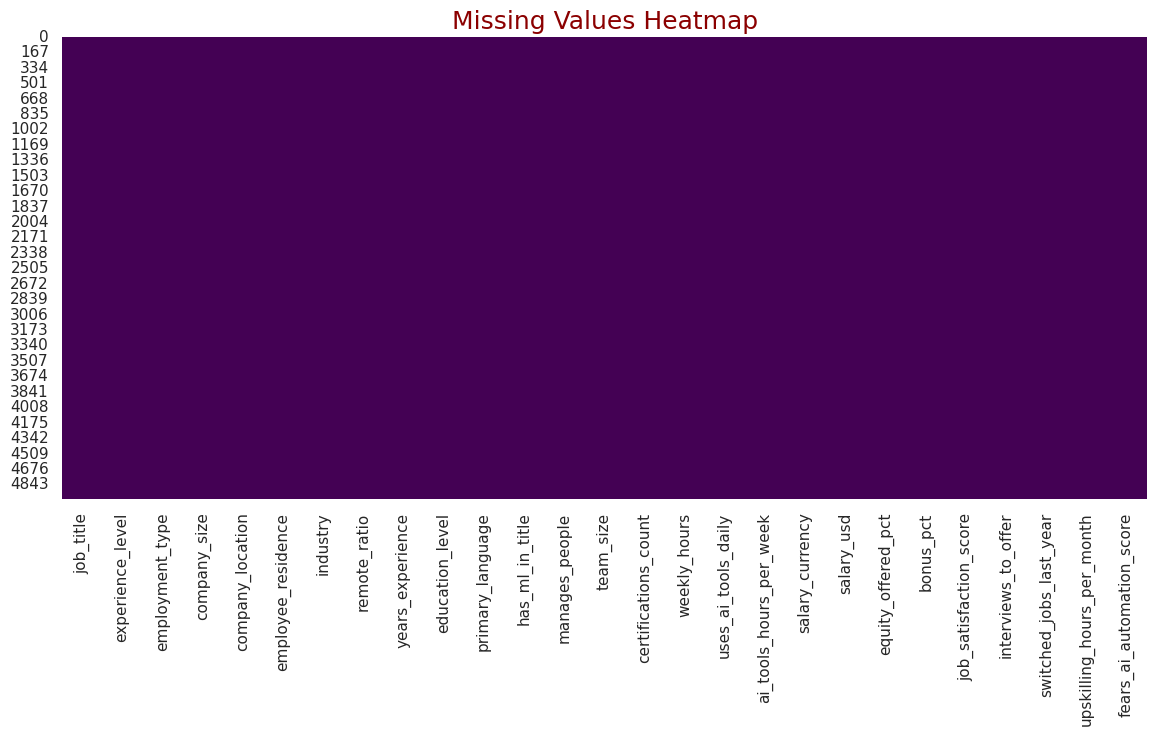

job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

Duplicate Rows : 0
Index(['remote_ratio', 'years_experience', 'team_size', 'certifications_count',
       'weekly_hours', 

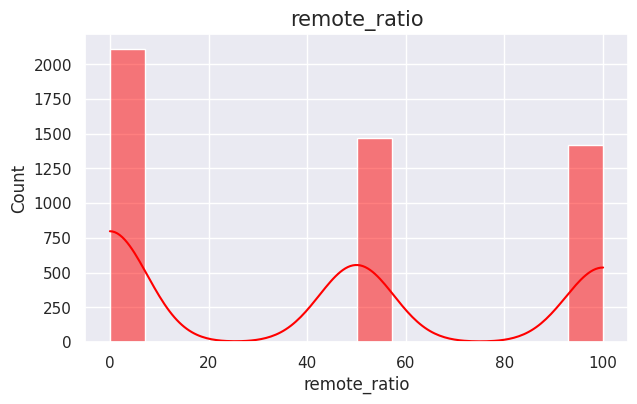

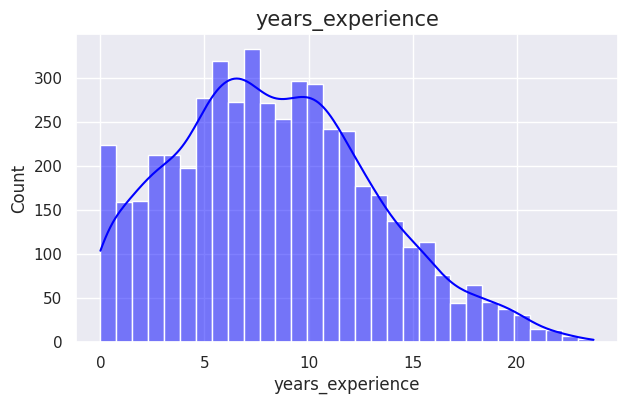

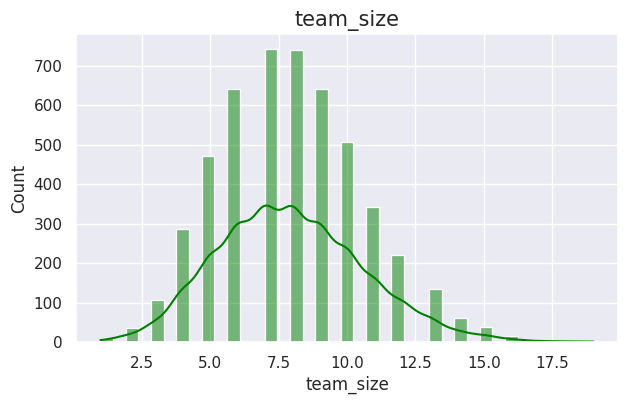

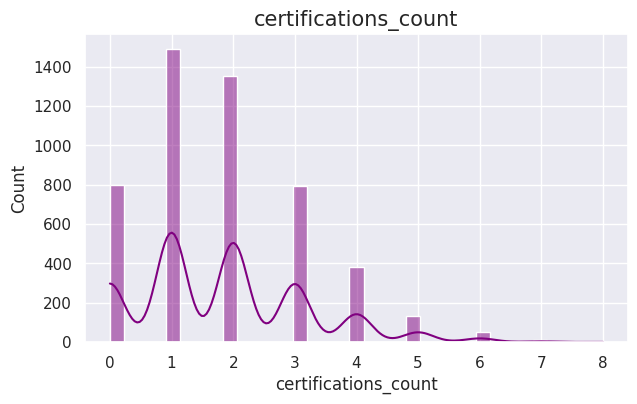

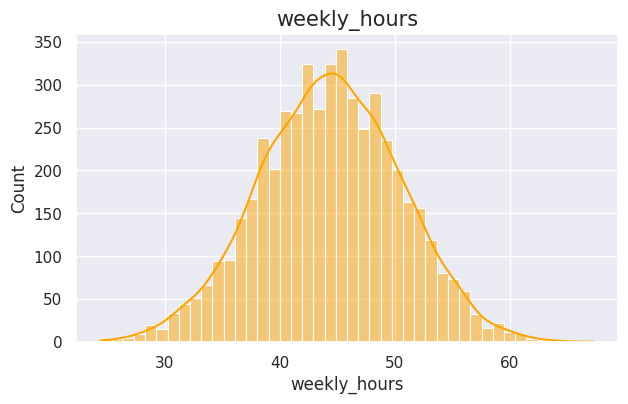

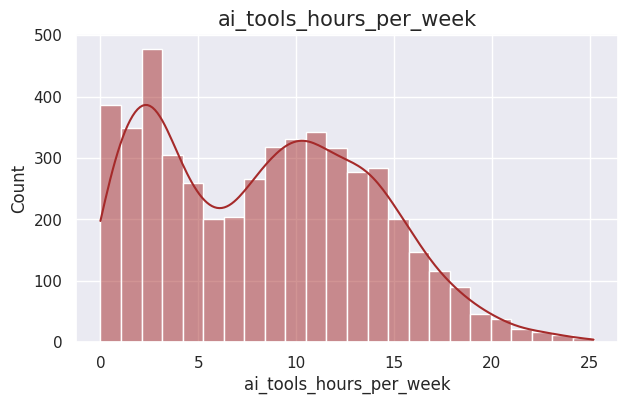

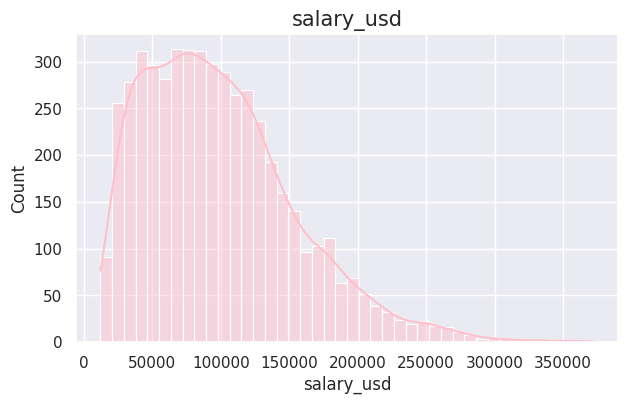

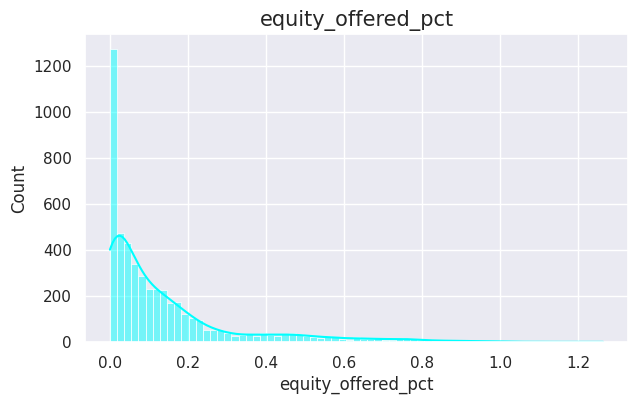

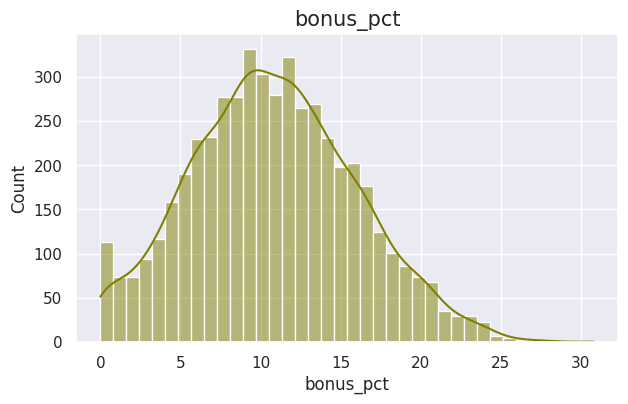

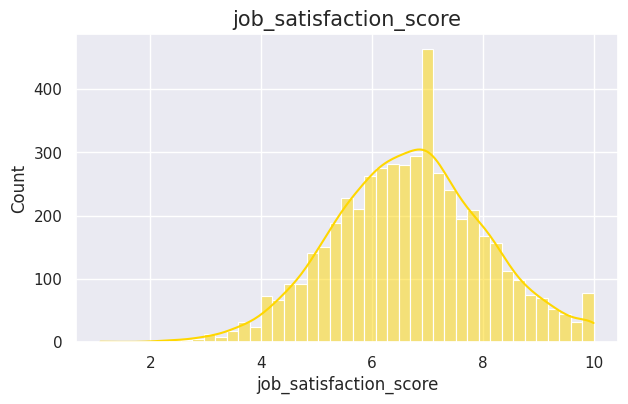

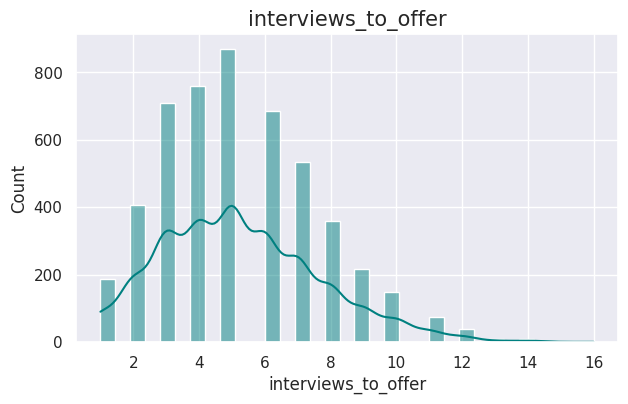

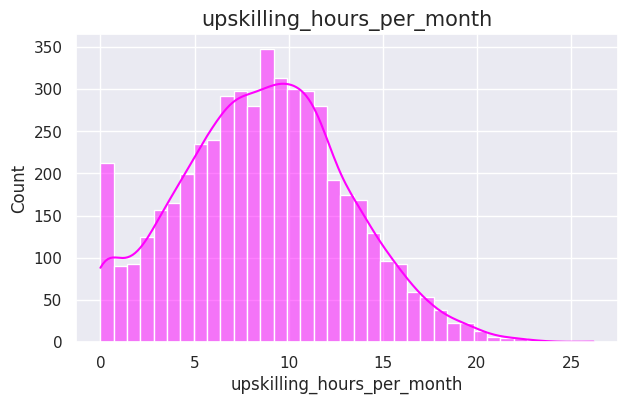

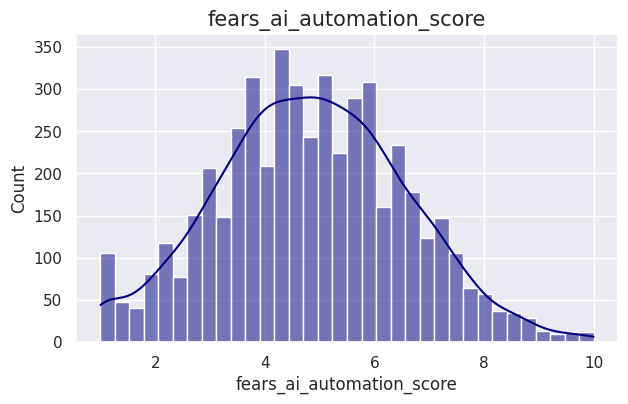

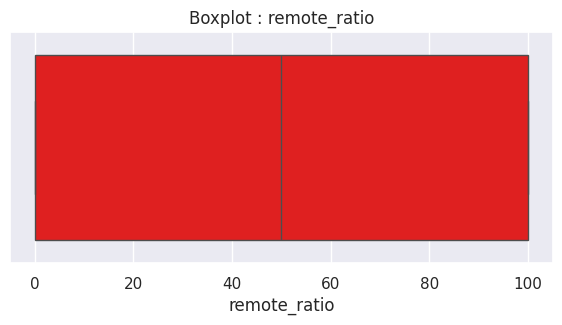

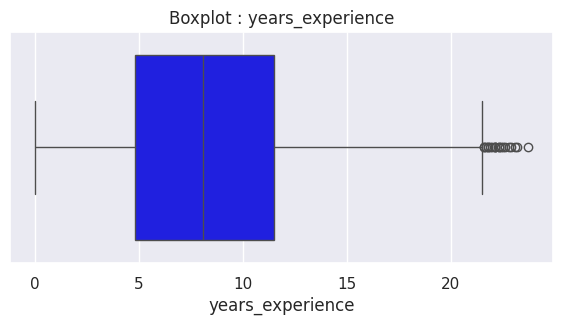

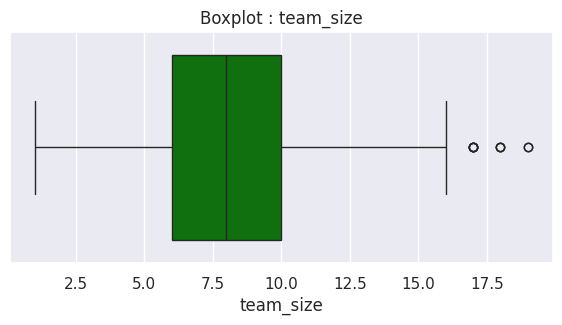

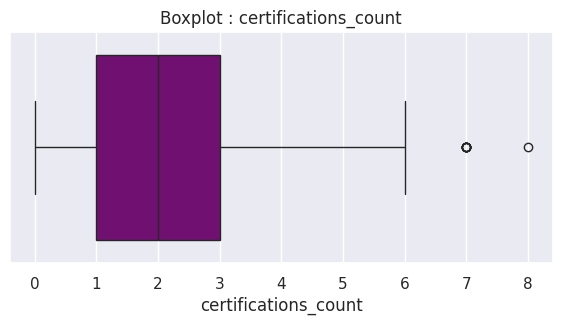

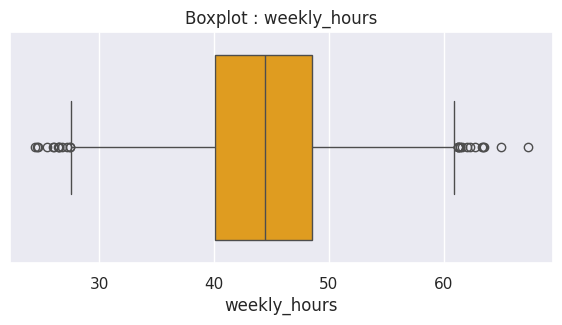

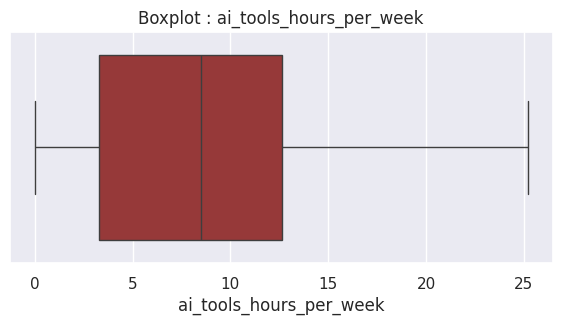

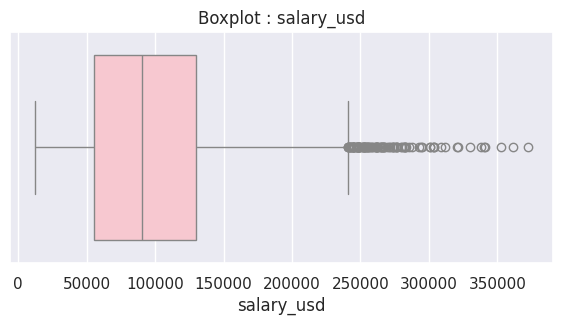

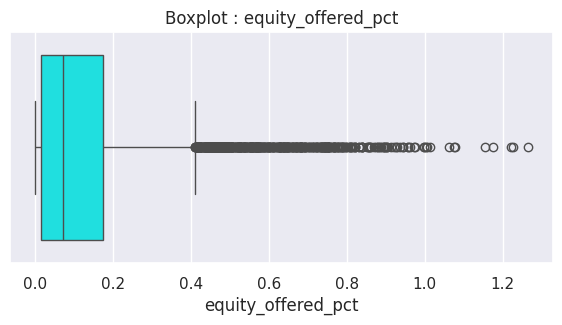

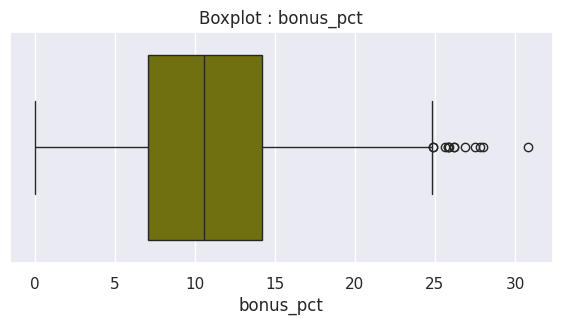

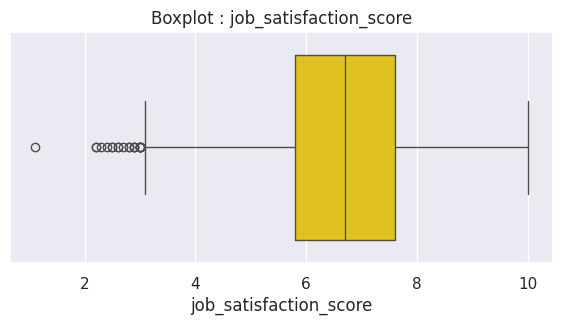

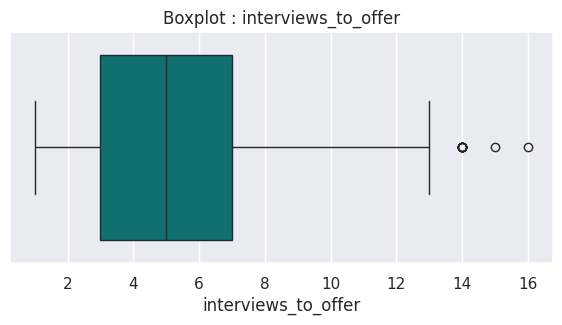

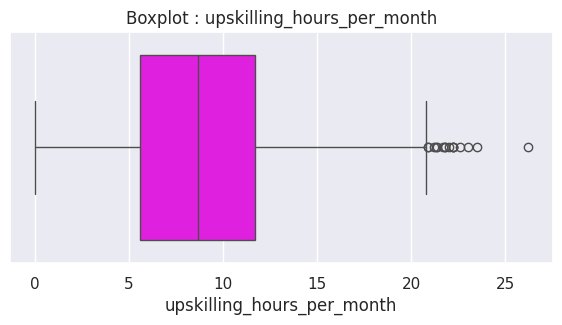

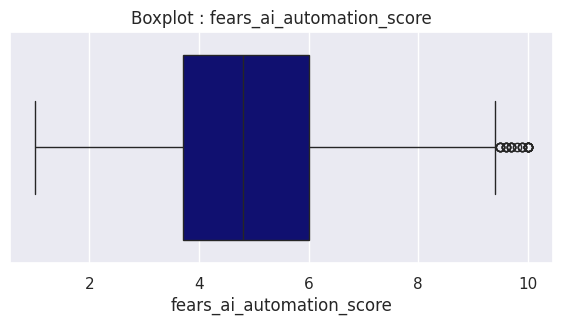

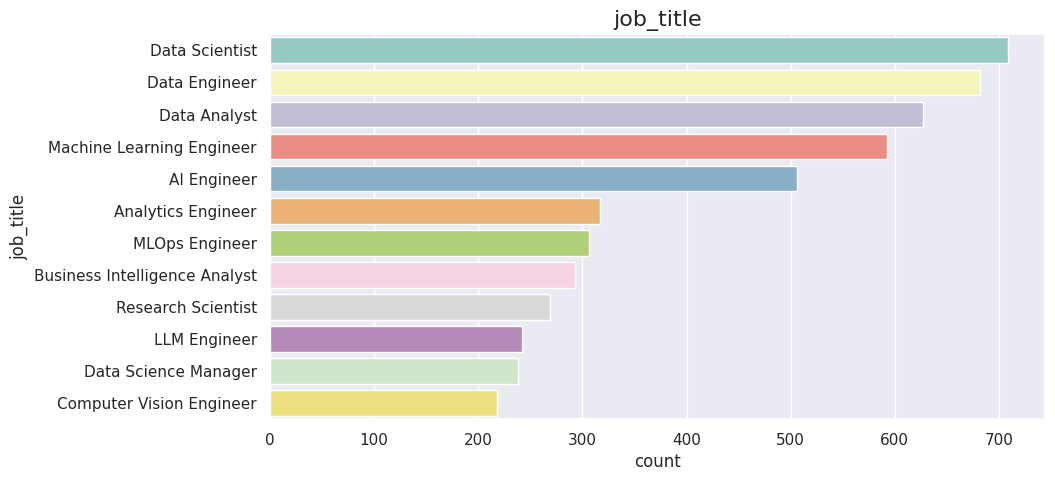

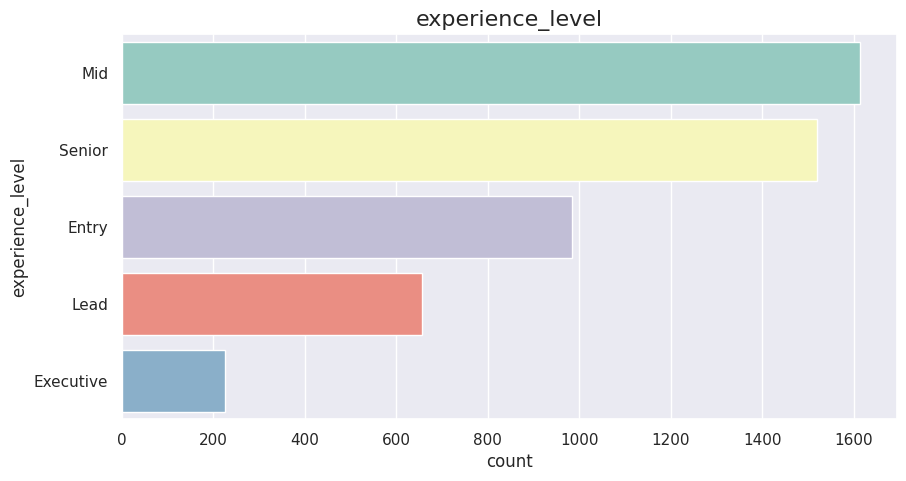

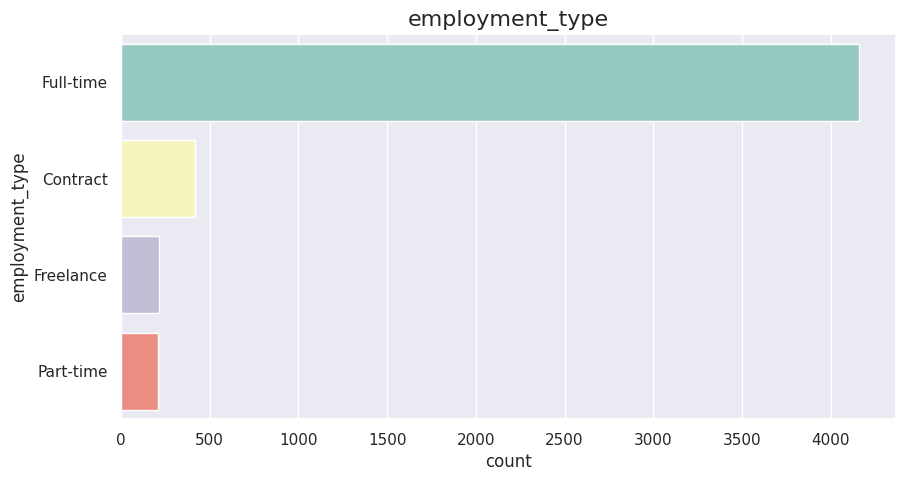

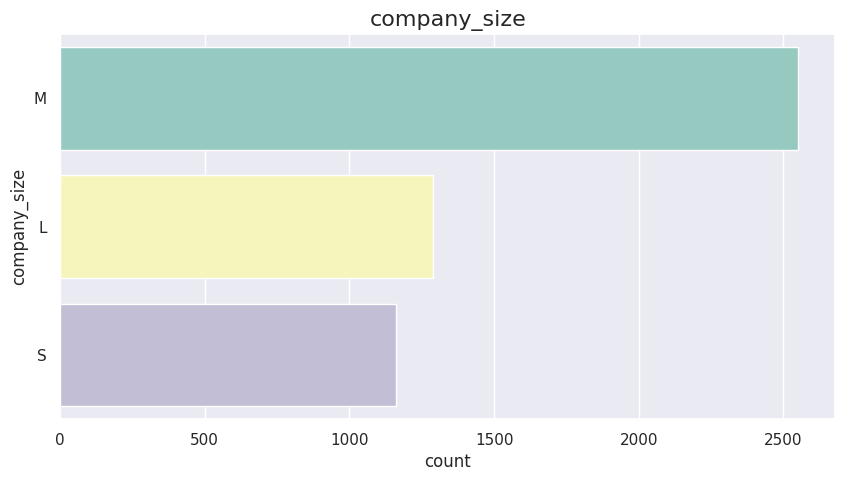

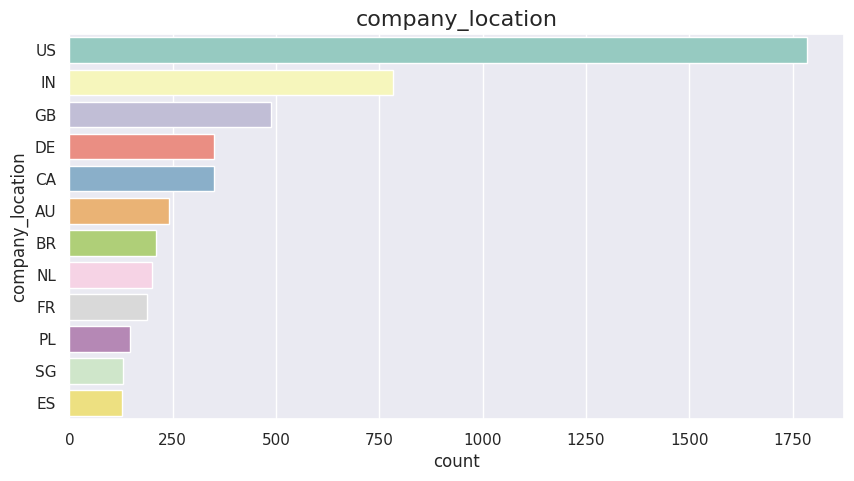

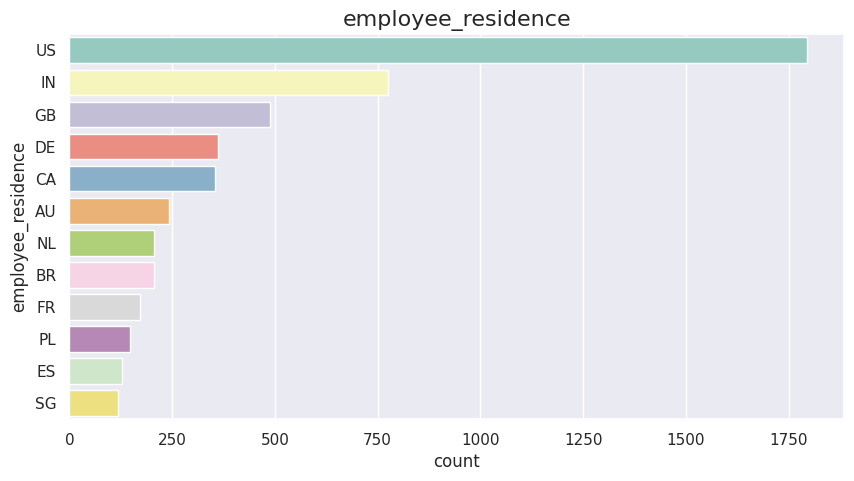

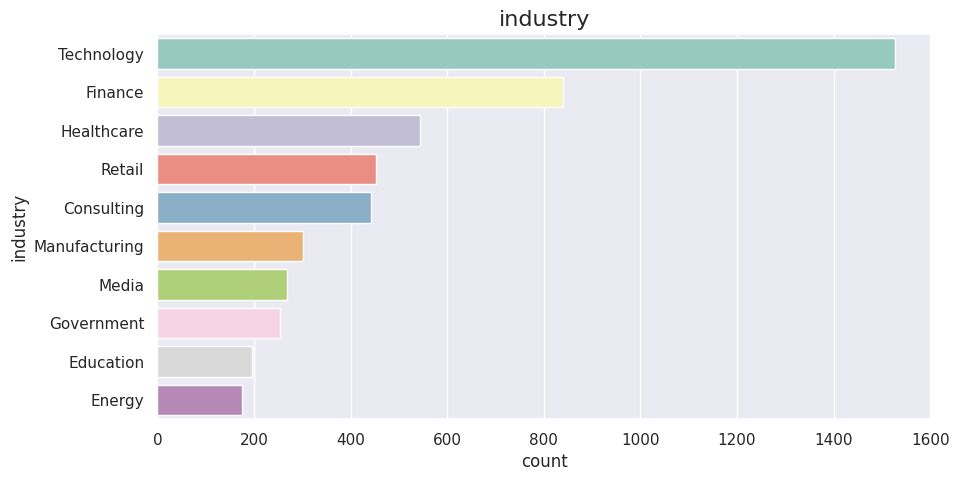

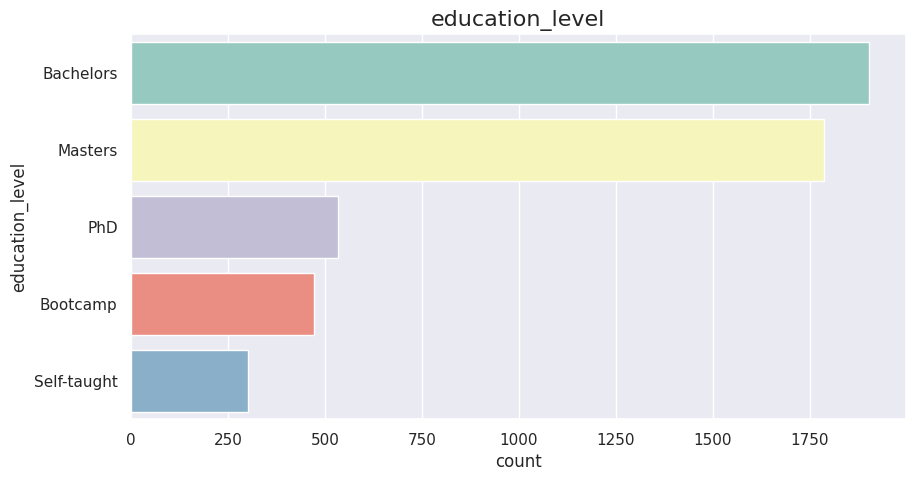

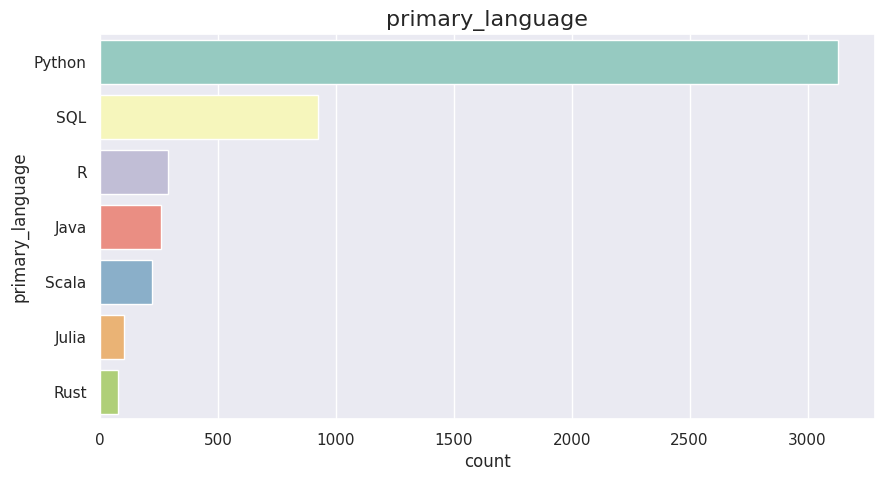

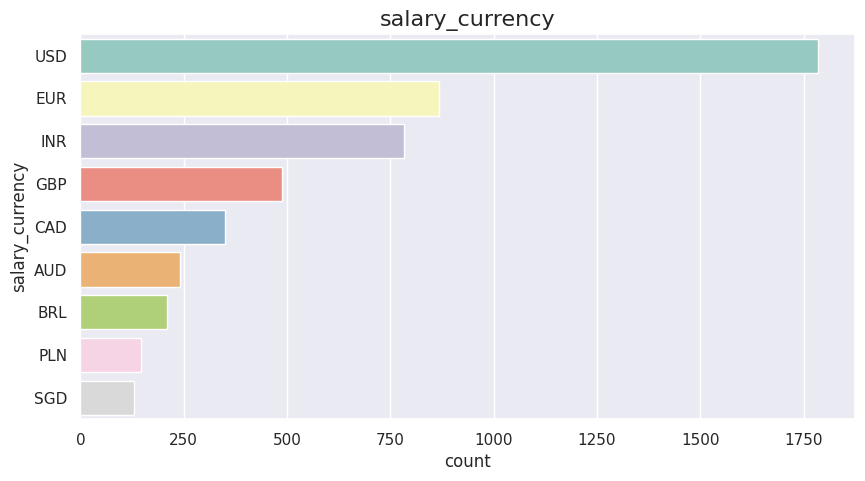

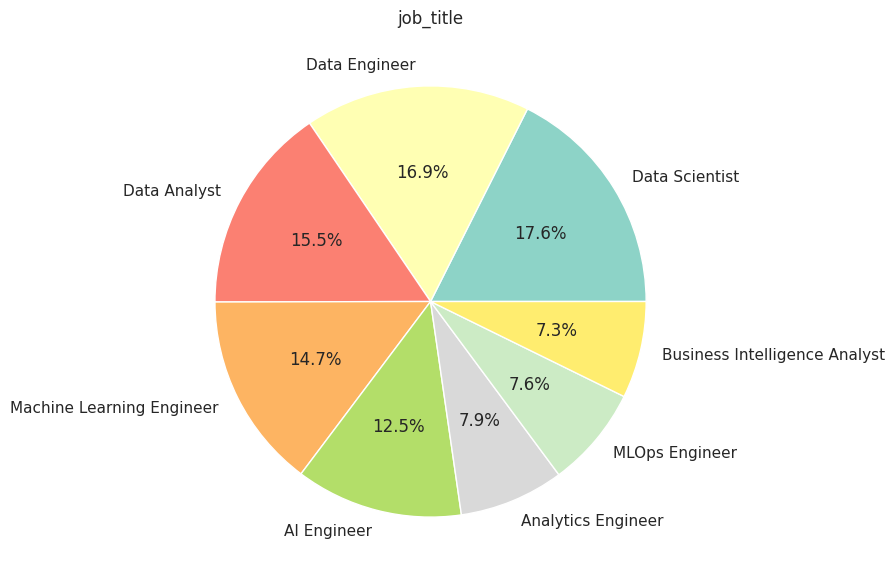

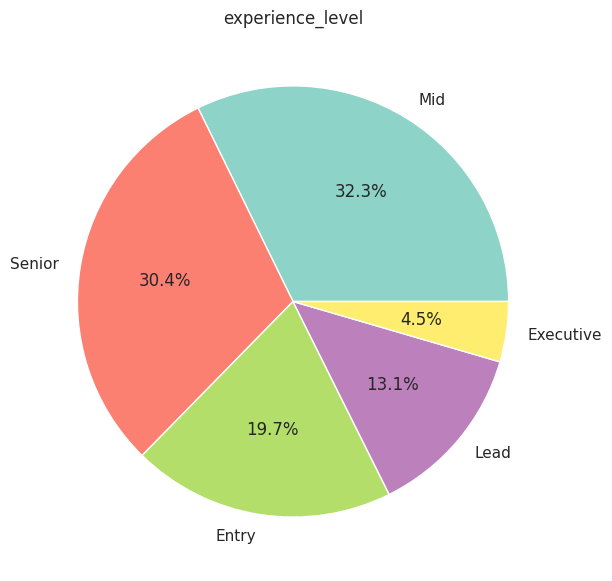

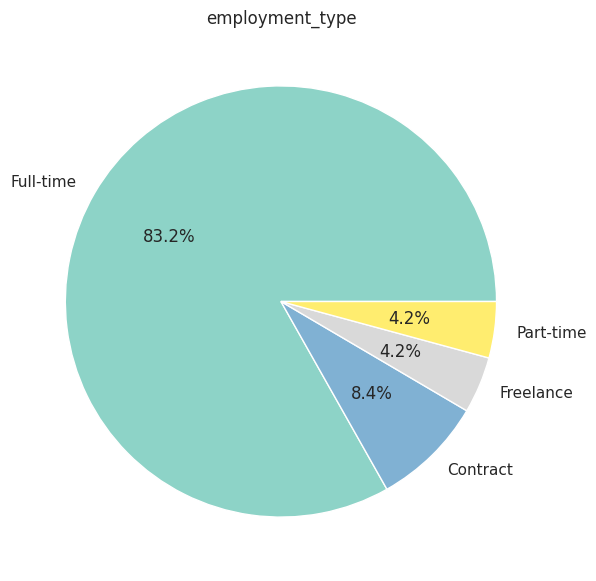

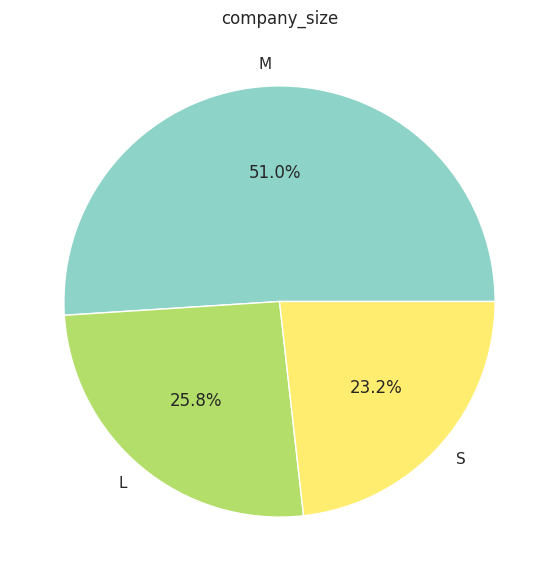

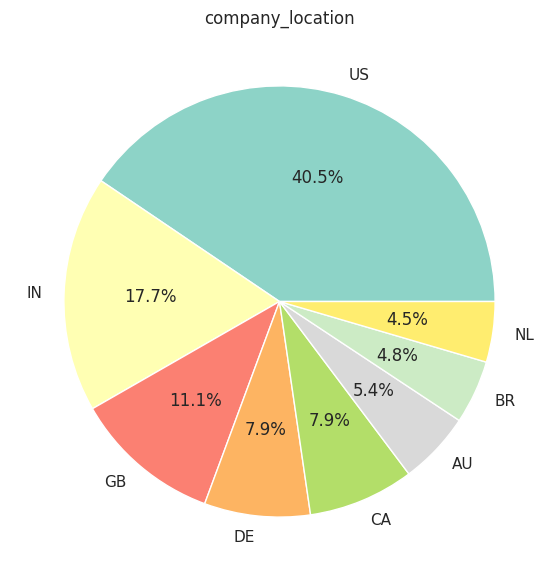

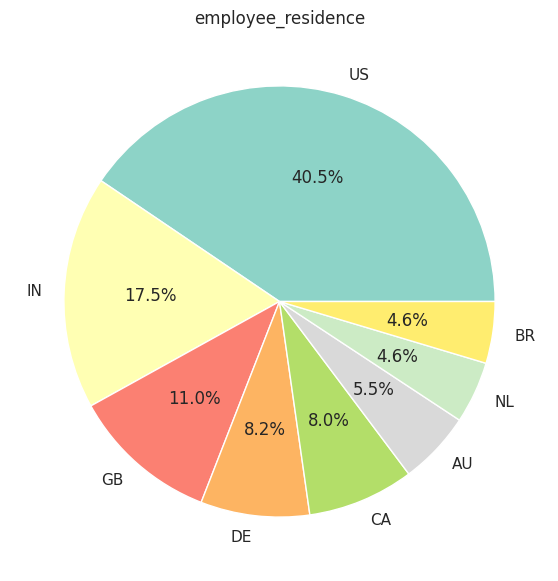

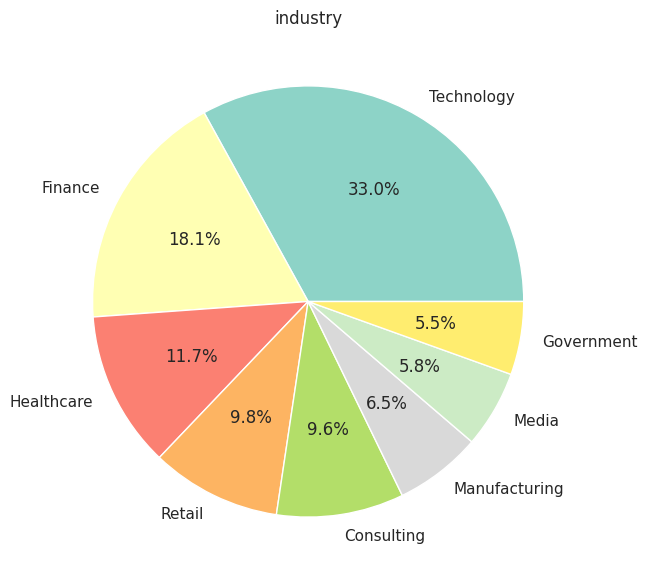

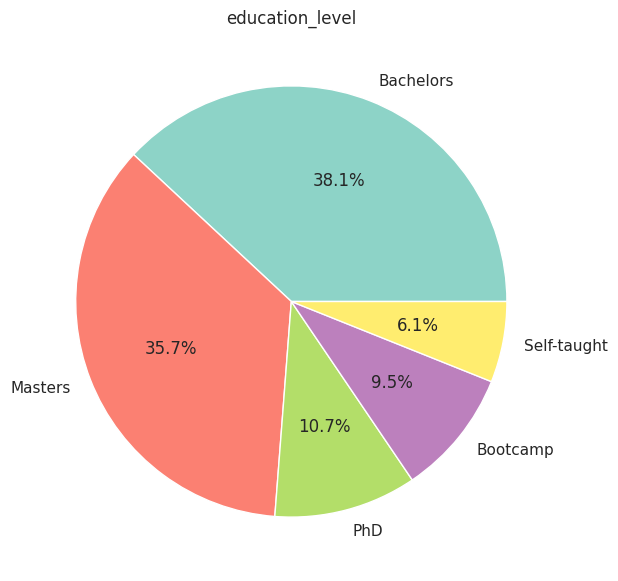

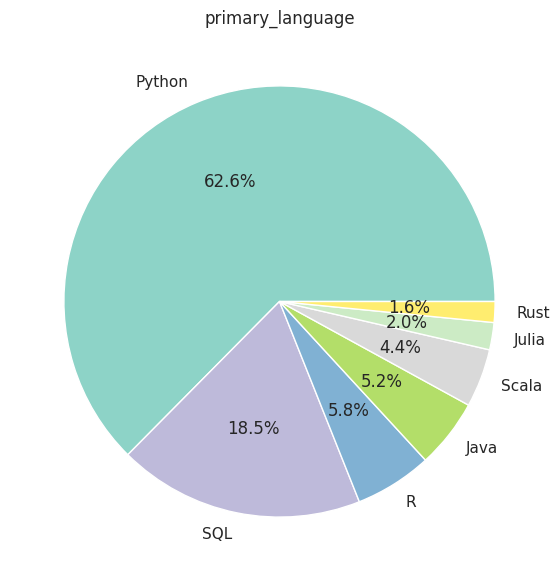

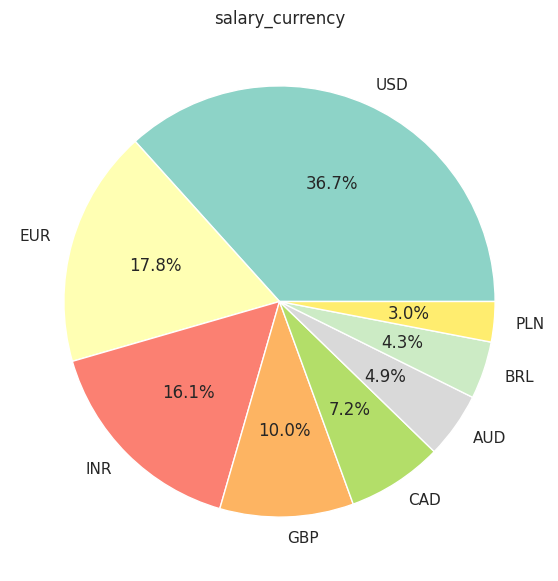

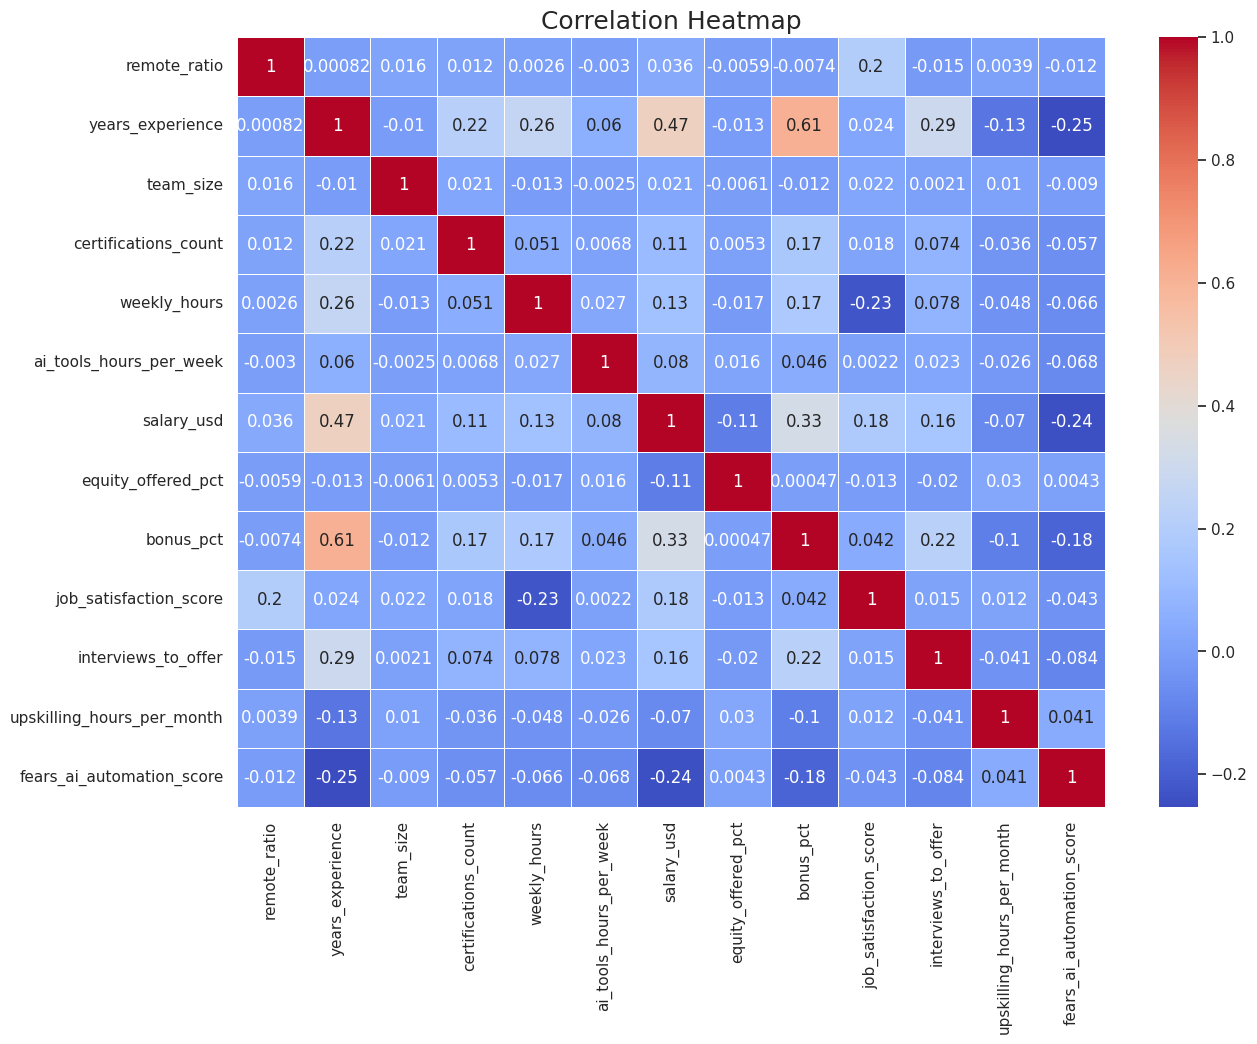

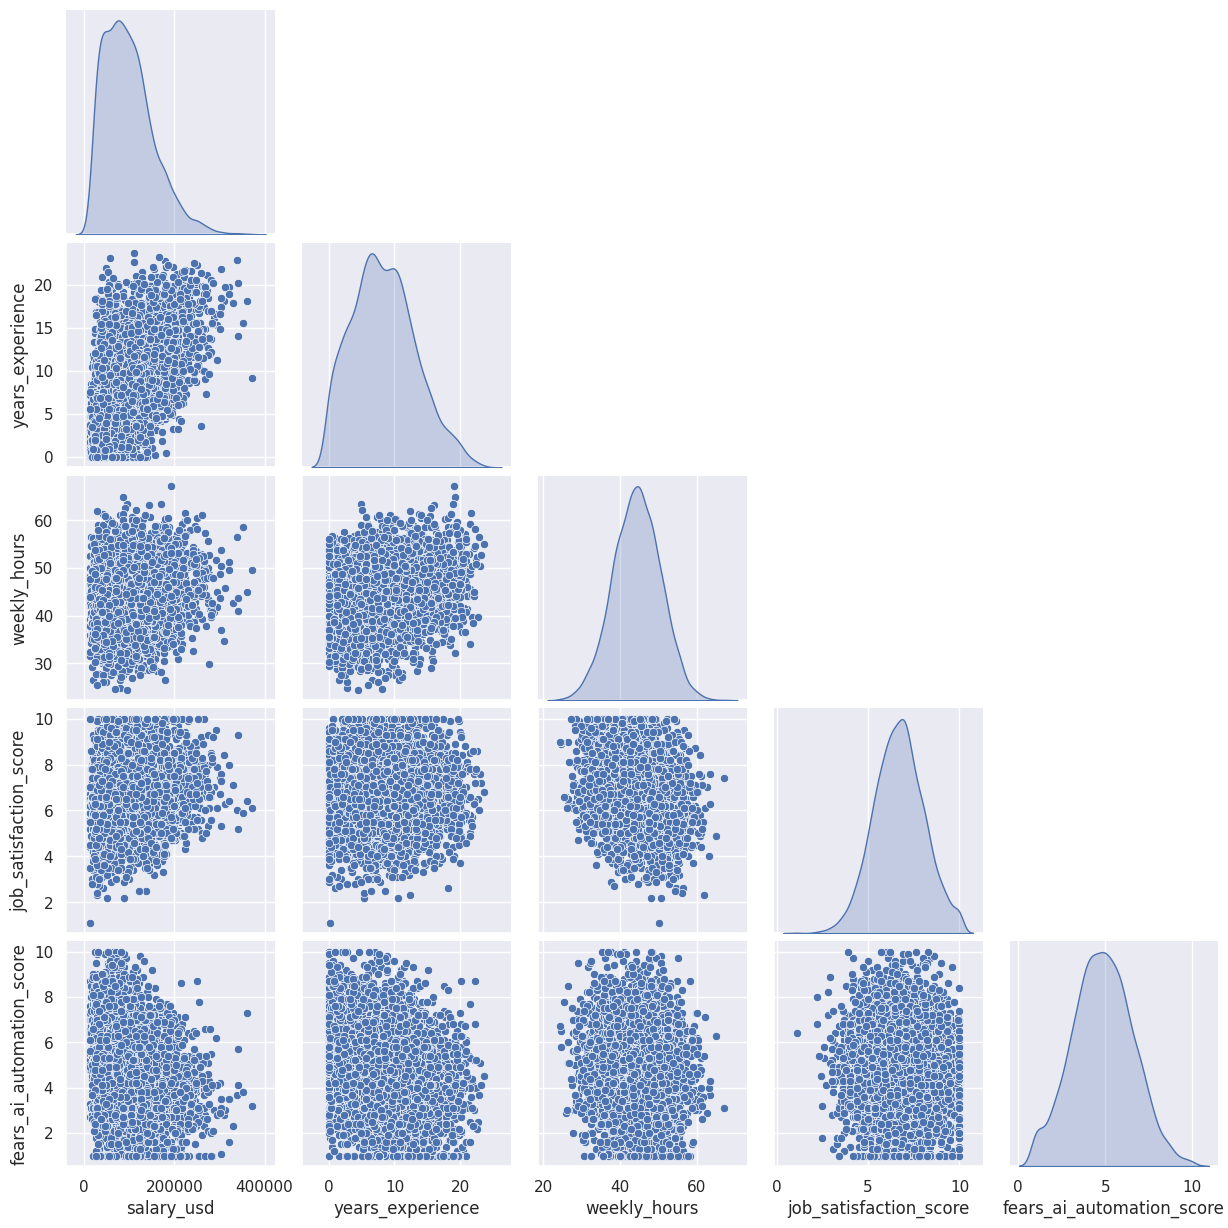

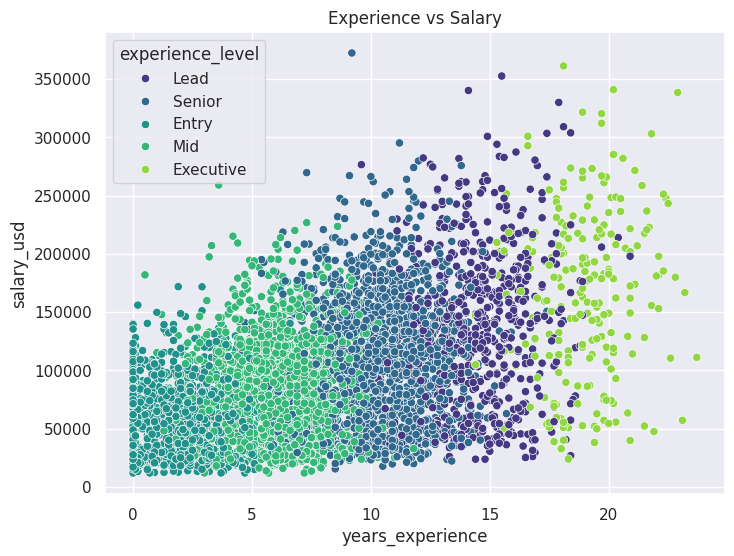

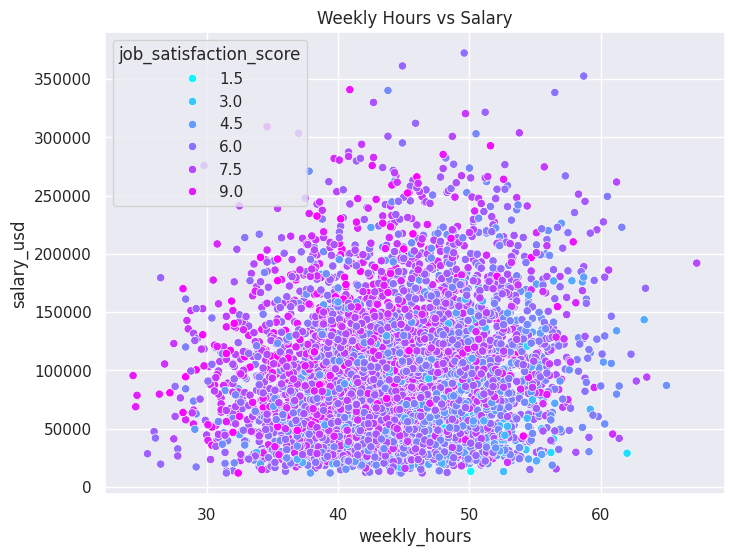

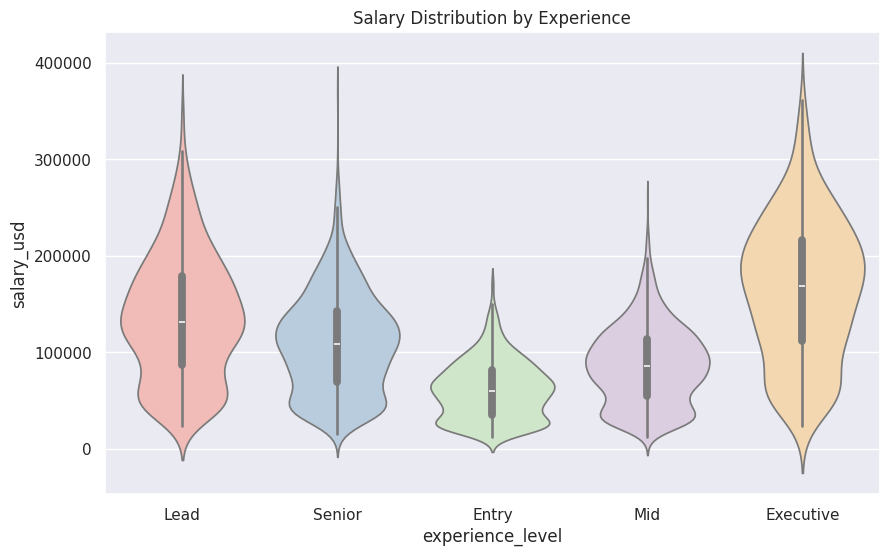

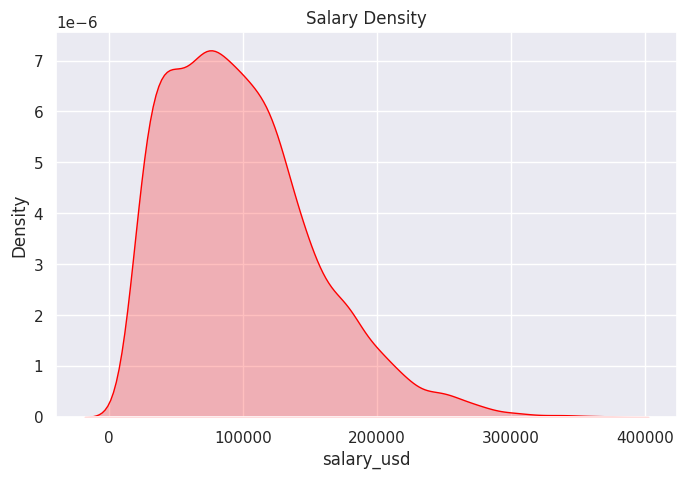

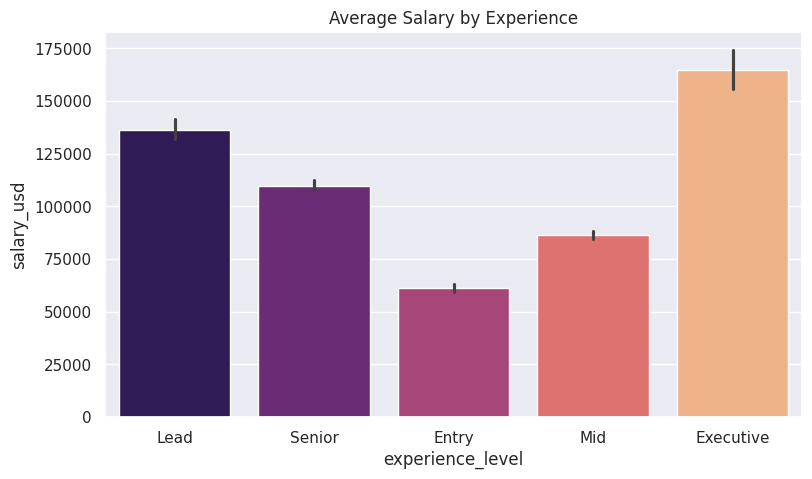

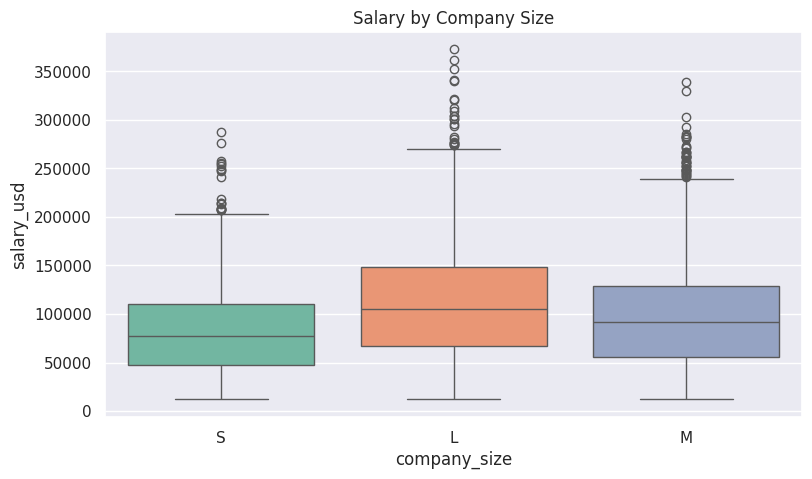

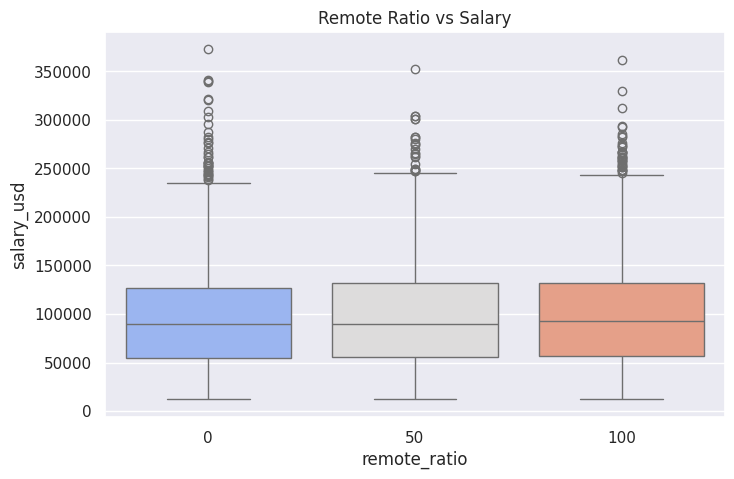

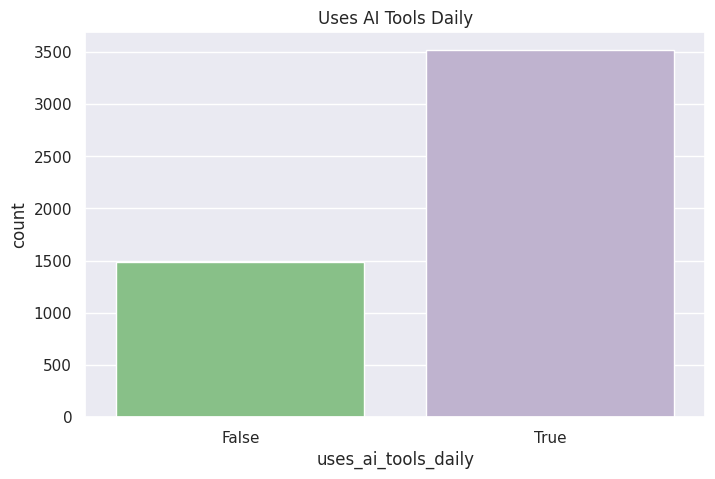

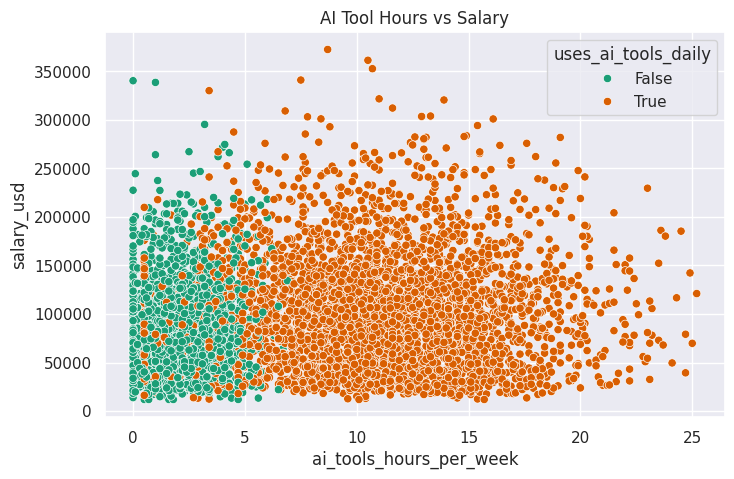

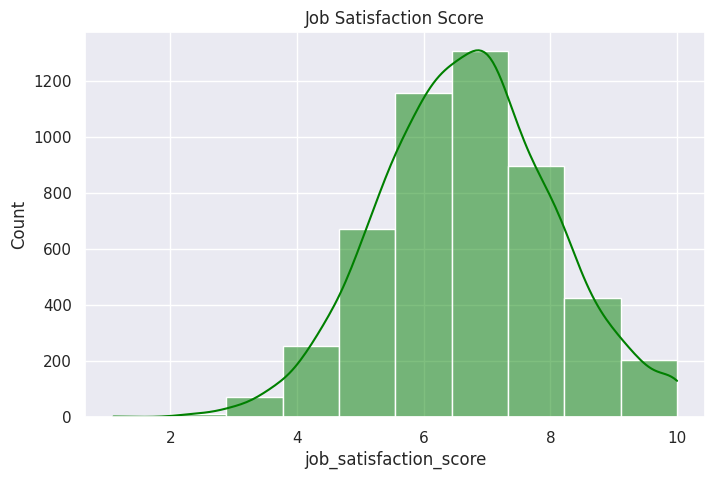

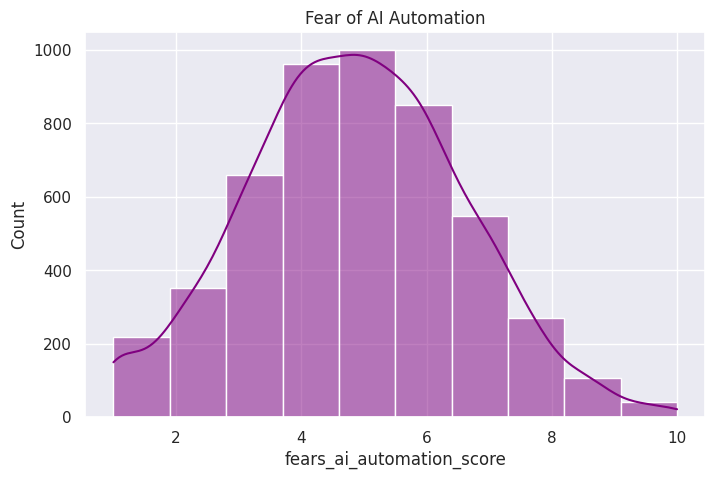

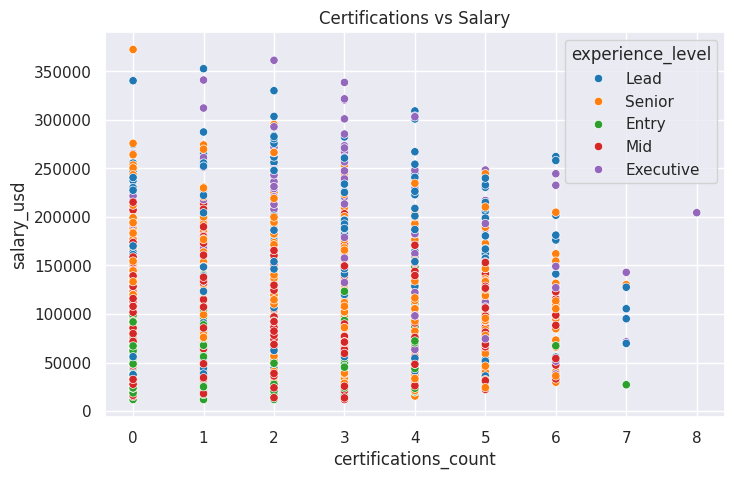

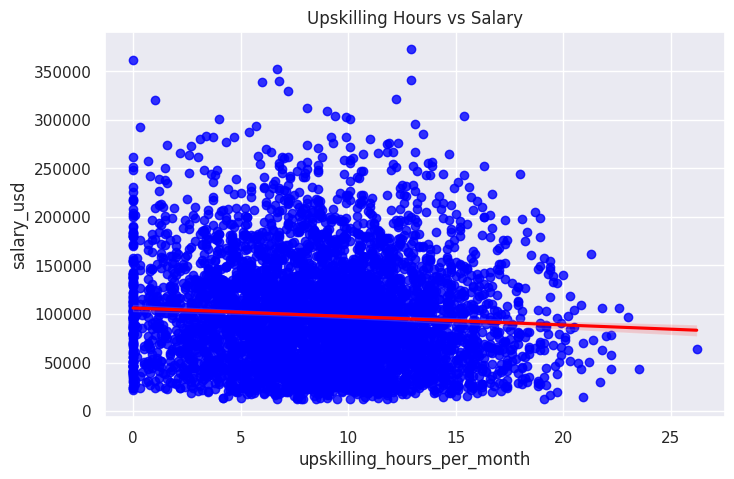

EDA Completed Successfully


In [12]:
import plotly.express as px

plt.style.use("ggplot")
sns.set(font_scale=1)

# ==========================================================
# LOAD DATASET
# ==========================================================

# df = pd.read_csv("your_dataset.csv")

print("="*60)
print("First Five Rows")
print("="*60)
print(df.head())

print("\nDataset Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe(include='all'))

# ==========================================================
# MISSING VALUES
# ==========================================================

plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values Heatmap",
          fontsize=18,
          color="darkred")

plt.show()

print(df.isnull().sum())

# ==========================================================
# DUPLICATES
# ==========================================================

print("\nDuplicate Rows :",df.duplicated().sum())

# ==========================================================
# NUMERICAL & CATEGORICAL
# ==========================================================

num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(include="object").columns

print(num_cols)
print(cat_cols)

# ==========================================================
# HISTOGRAMS
# ==========================================================

colors=[
"red","blue","green","purple","orange",
"brown","pink","cyan","olive","gold",
"teal","magenta","navy","lime","coral"
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(7,4))

    sns.histplot(df[col],
                 kde=True,
                 color=colors[i%len(colors)])

    plt.title(col,fontsize=15)

    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col],
                color=colors[i%len(colors)])

    plt.title("Boxplot : "+col)

    plt.show()

# ==========================================================
# COUNT PLOTS
# ==========================================================

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    sns.countplot(data=df,
                  y=col,
                  palette="Set3",
                  order=df[col].value_counts().index)

    plt.title(col,
              fontsize=16)

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

for col in cat_cols:

    plt.figure(figsize=(7,7))

    df[col].value_counts().head(8).plot.pie(
        autopct="%1.1f%%",
        cmap="Set3"
    )

    plt.ylabel("")

    plt.title(col)

    plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(14,10))

corr=df[num_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=.5)

plt.title("Correlation Heatmap",
          fontsize=18)

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

selected=[
"salary_usd",
"years_experience",
"weekly_hours",
"job_satisfaction_score",
"fears_ai_automation_score"
]

sns.pairplot(df[selected],
             corner=True,
             diag_kind="kde")

plt.show()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary_usd",
    hue="experience_level",
    palette="viridis"
)

plt.title("Experience vs Salary")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="weekly_hours",
    y="salary_usd",
    hue="job_satisfaction_score",
    palette="cool"
)

plt.title("Weekly Hours vs Salary")

plt.show()

# ==========================================================
# VIOLIN PLOT
# ==========================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="experience_level",
    y="salary_usd",
    palette="Pastel1"
)

plt.title("Salary Distribution by Experience")

plt.show()

# ==========================================================
# KDE PLOT
# ==========================================================

plt.figure(figsize=(8,5))

sns.kdeplot(
    df["salary_usd"],
    fill=True,
    color="red"
)

plt.title("Salary Density")

plt.show()

# ==========================================================
# EXPERIENCE ANALYSIS
# ==========================================================

plt.figure(figsize=(9,5))

sns.barplot(
    data=df,
    x="experience_level",
    y="salary_usd",
    estimator=np.mean,
    palette="magma"
)

plt.title("Average Salary by Experience")

plt.show()

# ==========================================================
# COMPANY SIZE ANALYSIS
# ==========================================================

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="company_size",
    y="salary_usd",
    palette="Set2"
)

plt.title("Salary by Company Size")

plt.show()

# ==========================================================
# REMOTE RATIO ANALYSIS
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="remote_ratio",
    y="salary_usd",
    palette="coolwarm"
)

plt.title("Remote Ratio vs Salary")

plt.show()

# ==========================================================
# AI TOOLS DAILY
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="uses_ai_tools_daily",
    palette="Accent"
)

plt.title("Uses AI Tools Daily")

plt.show()

# ==========================================================
# AI HOURS
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="ai_tools_hours_per_week",
    y="salary_usd",
    hue="uses_ai_tools_daily",
    palette="Dark2"
)

plt.title("AI Tool Hours vs Salary")

plt.show()

# ==========================================================
# JOB SATISFACTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["job_satisfaction_score"],
    bins=10,
    color="green",
    kde=True
)

plt.title("Job Satisfaction Score")

plt.show()

# ==========================================================
# FEAR OF AI AUTOMATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["fears_ai_automation_score"],
    bins=10,
    color="purple",
    kde=True
)

plt.title("Fear of AI Automation")

plt.show()

# ==========================================================
# CERTIFICATIONS
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="certifications_count",
    y="salary_usd",
    hue="experience_level",
    palette="tab10"
)

plt.title("Certifications vs Salary")

plt.show()

# ==========================================================
# UPSKILLING HOURS
# ==========================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="upskilling_hours_per_month",
    y="salary_usd",
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"}
)

plt.title("Upskilling Hours vs Salary")

plt.show()

# ==========================================================
# PLOTLY INTERACTIVE SCATTER
# ==========================================================

fig = px.scatter(
    df,
    x="years_experience",
    y="salary_usd",
    color="experience_level",
    size="certifications_count",
    hover_data=["job_title","industry"],
    title="Interactive Salary Analysis"
)

fig.show()

# ==========================================================
# PLOTLY SUNBURST
# ==========================================================

fig = px.sunburst(
    df,
    path=["industry","experience_level","employment_type"],
    values="salary_usd",
    color="salary_usd",
    color_continuous_scale="Turbo"
)

fig.show()

# ==========================================================
# PLOTLY TREEMAP
# ==========================================================

fig = px.treemap(
    df,
    path=["industry","job_title"],
    values="salary_usd",
    color="salary_usd",
    color_continuous_scale="Viridis"
)

fig.show()

# ==========================================================
# PLOTLY BOX
# ==========================================================

fig = px.box(
    df,
    x="experience_level",
    y="salary_usd",
    color="experience_level",
    title="Salary Distribution"
)

fig.show()

# ==========================================================
# END
# ==========================================================

print("="*70)
print("EDA Completed Successfully")
print("="*70)

## Feature engineering

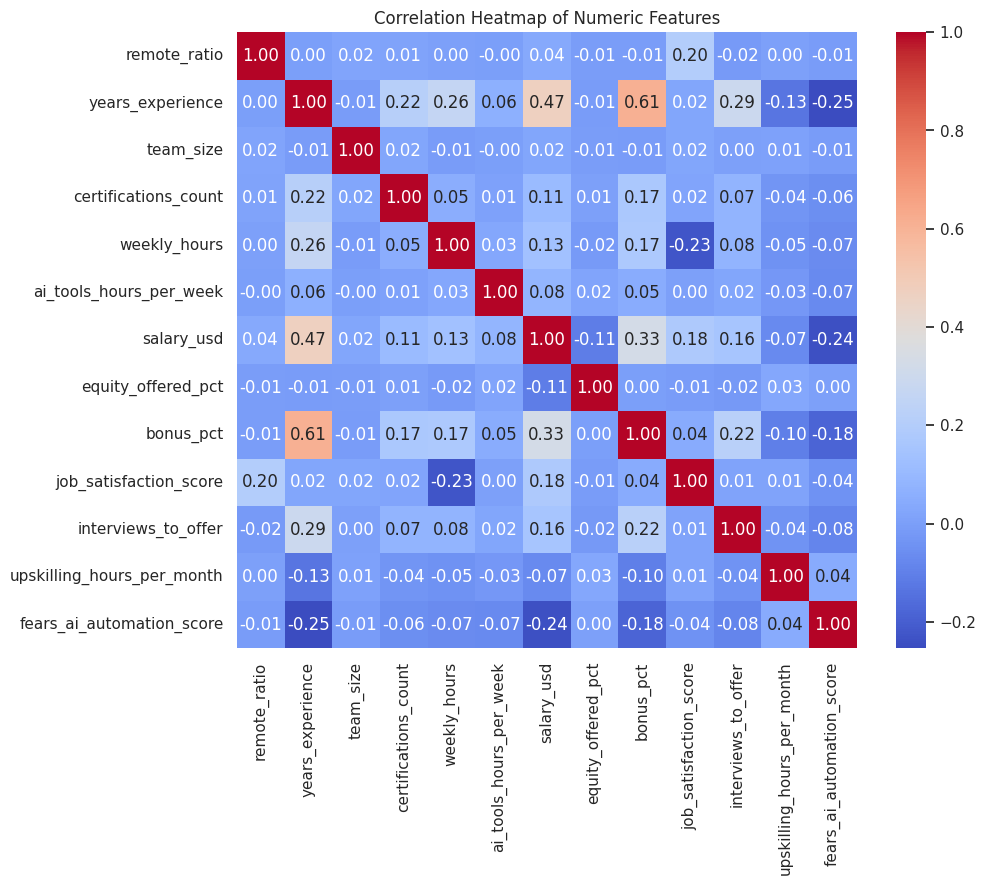

In [13]:
# Correlation heatmap (only if 4 or more numeric columns are available)
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

Number of features after encoding: 85
Linear Regression model R² score: 0.806
Linear Regression model Mean Absolute Error: 18113.78


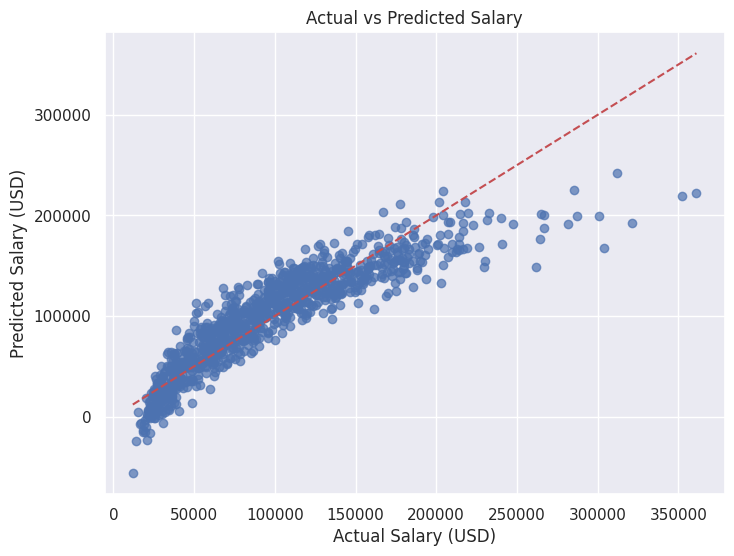

In [14]:
# Create a copy of the dataset for modeling
model_df = df.copy()

# Identify target and features
target = 'salary_usd'
# Remove target from features
features = model_df.drop(columns=[target])

# For simplicity, use pandas' get_dummies method for categorical encoding
# Identify categorical columns (strings and booleans are handled separately)
categorical_cols = features.select_dtypes(include=['object', 'bool']).columns

features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Align feature names if necessary
print(f'Number of features after encoding: {features_encoded.shape[1]}')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_encoded, model_df[target], test_size=0.2, random_state=42)

# Feature scaling for better convergence (using StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a simple Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = lr_model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Linear Regression model R² score: {r2:.3f}')
print(f'Linear Regression model Mean Absolute Error: {mae:.2f}')

# In case the reader wants to compare predictions, a plot of the predicted vs actual values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('Actual vs Predicted Salary')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## Thank you...pls upvote!!!!!!!!!